Volume shape: (266, 207, 270)
Nodule mask shape: (266, 207, 270)
Point label counts: {np.str_('anchor'): 8, np.str_('control'): 10}
Control points shape: (10, 3)
Anchor points shape: (8, 3)
Volume shape: (266, 207, 270)
Nodule mask shape: (266, 207, 270)
Nodule slices: [148 149 150 151 152 153]
98.071304 150.85364
98.071304 150.85364
98.071304 150.85364
Control point slices: [ 98 151]


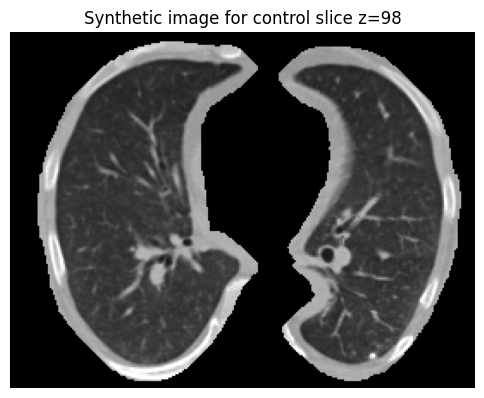

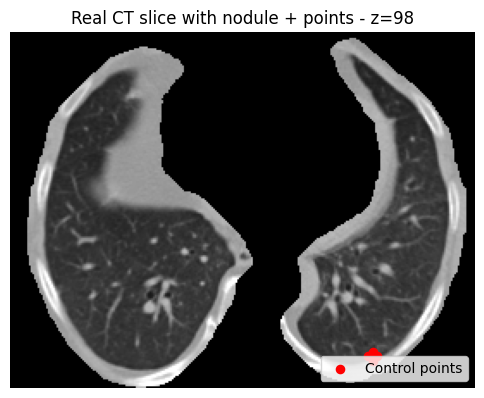

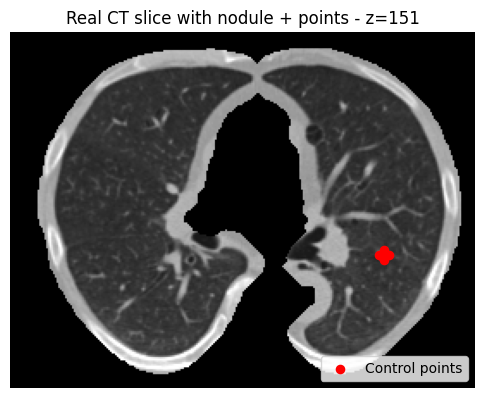

In [16]:
import os
import glob
import PIL
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import nibabel as nib

pio.renderers.default = "browser"

project_dir = "/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis"
output_path = os.environ.get(
    "SYNTHETIC_SURFACE_ROOT",
    os.path.join(project_dir, "data/luna16_saliency_synthetic_detector_top5_minprob0.5_shepard"),
)
processed_path = os.path.join(project_dir, "data/LUNA16_preprocessed")

scan_id = os.environ.get(
    "SYNTHETIC_SCAN_ID",
    "1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793540579077826395208",
)
available_scan_ids = sorted(d for d in os.listdir(output_path) if os.path.isdir(os.path.join(output_path, d)))
if scan_id not in available_scan_ids:
    raise ValueError(f"scan_id={scan_id} not found in {output_path}; available scans: {len(available_scan_ids)}")

scan_dir = os.path.join(output_path, scan_id)

volume_path = os.path.join(processed_path, scan_id, f"{scan_id}_volume.nii.gz")
mask_path = os.path.join(processed_path, scan_id, f"{scan_id}_nodule_mask.nii.gz")

volume_img = nib.load(volume_path)
mask_img = nib.load(mask_path)

volume = volume_img.get_fdata().astype(np.float32)
nodule_mask = mask_img.get_fdata() > 0

volume = volume.transpose(2, 1, 0)
nodule_mask = nodule_mask.transpose(2, 1, 0)

print("Volume shape:", volume.shape)
print("Nodule mask shape:", nodule_mask.shape)

grid_files = sorted(glob.glob(os.path.join(scan_dir, "surface_grid_float_*.npy")))

for grid_file in grid_files[:3]:

    z_grid = np.load(grid_file)
    basename = os.path.basename(grid_file)

    control_points_file = os.path.join(
        scan_dir,
        basename.replace("surface_grid_float_", "control_points_")
    )

    point_labels_file = os.path.join(
        scan_dir,
        basename.replace("surface_grid_float_", "point_labels_")
    )

    points = np.load(control_points_file, allow_pickle=True)
    point_labels = np.load(point_labels_file, allow_pickle=True).astype(str)
    point_labels = np.char.strip(np.char.lower(point_labels.astype(str)))
    print("Point label counts:", {label: int(np.sum(point_labels == label)) for label in np.unique(point_labels)})

    control_mask = np.isin(point_labels, ["control", "detector", "fallback"])
    control_points = points[control_mask]
    if control_points.size == 0 and points.ndim == 2 and points.shape[1] == 3:
        print("Warning: no explicit control/detector labels found; using all non-anchor points.")
        control_points = points[point_labels != "anchor"]
    print("Control points shape:", control_points.shape)
    anchor_points = points[point_labels == "anchor"]
    print("Anchor points shape:", anchor_points.shape)

    fig = go.Figure()

    fig.add_trace(
        go.Surface(
            z=z_grid,
            colorscale="Viridis",
            showscale=True,
            opacity=0.75,
            name="TPS surface"
        )
    )

    nz, ny, nx = np.where(nodule_mask)

    if len(nz) > 0:
        fig.add_trace(
            go.Scatter3d(
                x=nx,
                y=ny,
                z=nz,
                mode="markers",
                marker=dict(size=3, color="orange", opacity=0.75),
                name="Nodule voxels"
            )
        )

    if len(control_points) > 0:
        fig.add_trace(
            go.Scatter3d(
                x=control_points[:, 2],
                y=control_points[:, 1],
                z=control_points[:, 0],
                mode="markers",
                marker=dict(size=7, color="red", symbol="circle"),
                name="Control points"
            )
        )

    if len(anchor_points) > 0:
        fig.add_trace(
            go.Scatter3d(
                x=anchor_points[:, 2],
                y=anchor_points[:, 1],
                z=anchor_points[:, 0],
                mode="markers",
                marker=dict(size=7, color="cyan", symbol="diamond"),
                name="Anchor points"
            )
        )

    fig.update_layout(
        title=f"TPS surface + nodules: {basename}",
        width=1100,
        height=850,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z slice",
            aspectmode="data",
        ),
        legend=dict(x=0.02, y=0.98)
    )

    fig.show()


# Plot real CT slices containing nodules
nodule_slices = np.unique(np.where(nodule_mask)[0])

print("Volume shape:", volume.shape)
print("Nodule mask shape:", nodule_mask.shape)

print("Nodule slices:", nodule_slices)

max_slices_to_show = 12

if control_points.ndim == 2 and len(control_points) > 0:
    print(control_points[:, 0].min(), control_points[:, 0].max())
else:
    print("No control points found or invalid shape:", control_points.shape)

print(z_grid.min(), z_grid.max())
print(z_grid.min(), z_grid.max())

if len(nodule_slices) > max_slices_to_show:
    idx = np.linspace(
        0,
        len(nodule_slices) - 1,
        max_slices_to_show,
        dtype=int
    )
    nodule_slices = nodule_slices[idx]

control_slices = np.unique(np.round(control_points[:, 0]).astype(int))
print("Control point slices:", control_slices)

synthetic_images_dir = os.path.join("/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/data/luna16_saliency_synthetic_detector_top5_minprob0.5_shepard", scan_id, "surface_" + scan_id)
synthetic_image = PIL.Image.open(os.path.join(synthetic_images_dir + ".png"))
# Plot synthetic image for the first control slice
plt.figure(figsize=(6, 6))
plt.imshow(synthetic_image, cmap="gray")
plt.title(f"Synthetic image for control slice z={control_slices[0]}")
plt.axis("off")
plt.show()

# Plot real CT slices containing nodules + control/anchor points
for z in control_slices:
    ct_slice = volume[z]
    mask_slice = nodule_mask[z]

    ct_vis = np.clip(ct_slice, -1000, 400)
    ct_vis = (ct_vis + 1000) / 1400

    plt.figure(figsize=(6, 6))
    plt.imshow(ct_vis, cmap="gray")
    plt.contour(mask_slice, colors="red", linewidths=1.5)

    # control points on this slice
    if len(control_points) > 0:
        cp_on_slice = control_points[
            np.round(control_points[:, 0]).astype(int) == int(z)
        ]

        if len(cp_on_slice) > 0:
            plt.scatter(
                cp_on_slice[:, 2],
                cp_on_slice[:, 1],
                c="red",
                s=35,
                marker="o",
                label="Control points"
            )

    # anchor points on this slice
    if len(anchor_points) > 0:
        ap_on_slice = anchor_points[
            np.round(anchor_points[:, 0]).astype(int) == int(z)
        ]

        if len(ap_on_slice) > 0:
            plt.scatter(
                ap_on_slice[:, 2],
                ap_on_slice[:, 1],
                c="cyan",
                s=45,
                marker="D",
                label="Anchor points"
            )

    plt.title(f"Real CT slice with nodule + points - z={z}")
    plt.axis("off")
    plt.legend(loc="lower right")
    plt.show()